# Create a Simple Reflex-Based Lunar Lander Agent

In this example, we will use Gymnasium, an environment to train agents via reinforcement learning (RL). We will not use RL here but just use the environment with a custom simple reflex-based agent. 

## Install Gymnasium

The documentation for Gymnasium is available at https://gymnasium.farama.org/ 

Steps:
1. Create a new folder and open it with VS Code and install all needed Python Extensions in VS Code.
2. Create a new virtual environment (CTRL-Shift P Python Create Environment...)
3. I needed to install swig and the Python C++ headers on WSL2 via the terminal
    * `sudo apt install swig`
    * `sudo apt-get install python3-dev` 
4. Install python libraries for gymnasium with the needed extras

In [49]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "swig>=4,<5" "gymnasium[box2d,classic-control]>=1.0,<2"

Additional installs for screen capturing so environment visualizations can be converted to embedded videos.
For recording videos, I had to install
    
* `sudo apt-get install xvfb ffmpeg`

Additional python packages for screen capturing.

In [50]:
# Google Colab or if you are missing a package: Uncomment the %pip command below, run this block, and restart the session.
# %pip install -q "pyvirtualdisplay>=3,<4" "gymnasium[other]>=1.0,<2"

## The Lunar Lander Environment 

![Luna Lander image](https://gymnasium.farama.org/_images/lunar_lander.gif)

The documentation of the environment is available at: https://gymnasium.farama.org/environments/box2d/lunar_lander/

* Performance Measure: A reward of -100 or +100 points for crashing or landing safely respectively. We do not use 
  intermediate rewards here.

* Environment: This environment is a classic rocket trajectory optimization problem. A ship needs to land safely. The space is **continuous** with
  x and y coordinates in the range [-2.5, 2.5]. The landing pad is at coordinate (0,0).

* Actuators:  According to Pontryagin’s
  maximum principle, it is optimal to fire the engine at full throttle or turn it off. This is the reason why this environment has discrete actions: engine on or off. There are four discrete actions available:

    - 0: do nothing
    - 1: fire left orientation engine
    - 2: fire main engine
    - 3: fire right orientation engine

* Sensors: Each observation is an 8-dimensional vector: the coordinates of the lander in x & y, its linear velocities in x & y, its angle, its angular velocity, and two booleans that represent whether each leg is in contact with the ground or not.

The different ranges/settings of the environment can be queried.

In [51]:
import gymnasium as gym
import numpy as np
np.set_printoptions(precision=2)

In [52]:
def query_environment(name):
    env = gym.make(name)
    print(f"Action Space: {env.action_space}")
    print(f"Observation Space: {env.observation_space}")
    print(f"Max Episode Steps: {env.spec.max_episode_steps}")
    print(f"Nondeterministic: {env.spec.nondeterministic}")
   # print(f"Reward Range: {env.reward_range}")
    print(f"Reward Threshold: {env.spec.reward_threshold}")
    env.close()

query_environment("LunarLander-v3")

Action Space: Discrete(4)
Observation Space: Box([ -2.5   -2.5  -10.   -10.    -6.28 -10.    -0.    -0.  ], [ 2.5   2.5  10.   10.    6.28 10.    1.    1.  ], (8,), float32)
Max Episode Steps: 1000
Nondeterministic: False
Reward Threshold: 200



Gymnasium environments are implemented as classes with a `make` method to create the environment, a `reset` method, and a `step` method to execute an action.
To use it with an agent function that expects percepts and returns an action, we need write glue code that connects the environment with the agent function.

In [53]:
def run_episode(agent_function, env, max_steps=1000, verbose = True, render = True):
    """Run one episode in the environment using the provided agent."""

    # Reset the environment to generate the first observation (use seed=42 in reset to get reproducible results)
    observation, info = env.reset()

    # run one episode
    for _ in range(max_steps):
        # call the agent function to select an action
        action = agent_function(observation)

        if verbose:
            print (f"Obs: {observation} -> Action: {action}")

        # step: execute an action in the environment
        observation, reward, terminated, truncated, info = env.step(action)

        # render the environment
        if render:
            env.render()

        if terminated:
            if verbose:
                print(f"Final Reward: {reward}")
            break
    
    return reward

## Example: A Random Agent

We randomly return one of the actions. The environment accepts the integers 0-3.


In [54]:
def random_agent_function(observation): 
    """A random agent that selects actions uniformly at random. It ignores the observation."""
    return np.random.choice([0, 1, 2, 3], p=[0.25, 0.25, 0.25, 0.25])

Run an episode.

In [55]:
env = gym.make("LunarLander-v3", render_mode="human")

run_episode(random_agent_function, env)

env.close()

Obs: [-0.01  1.41 -0.79 -0.19  0.01  0.18  0.    0.  ] -> Action: 2
Obs: [-0.02  1.4  -0.77 -0.16  0.02  0.19  0.    0.  ] -> Action: 0
Obs: [-0.02  1.4  -0.77 -0.19  0.03  0.19  0.    0.  ] -> Action: 0
Obs: [-0.03  1.39 -0.77 -0.21  0.04  0.19  0.    0.  ] -> Action: 2
Obs: [-0.04  1.39 -0.77 -0.2   0.05  0.19  0.    0.  ] -> Action: 1
Obs: [-0.05  1.38 -0.78 -0.22  0.06  0.23  0.    0.  ] -> Action: 2
Obs: [-0.05  1.38 -0.77 -0.21  0.07  0.24  0.    0.  ] -> Action: 0
Obs: [-0.06  1.37 -0.77 -0.24  0.08  0.24  0.    0.  ] -> Action: 2
Obs: [-0.07  1.37 -0.76 -0.22  0.1   0.26  0.    0.  ] -> Action: 0
Obs: [-0.08  1.36 -0.76 -0.24  0.11  0.26  0.    0.  ] -> Action: 2
Obs: [-0.08  1.36 -0.77 -0.21  0.12  0.27  0.    0.  ] -> Action: 0
Obs: [-0.09  1.35 -0.77 -0.23  0.14  0.27  0.    0.  ] -> Action: 1
Obs: [-0.1   1.35 -0.77 -0.26  0.15  0.3   0.    0.  ] -> Action: 0
Obs: [-0.11  1.34 -0.77 -0.29  0.17  0.3   0.    0.  ] -> Action: 3
Obs: [-0.11  1.34 -0.76 -0.31  0.18  0.25  0.   

Gymnasium displays environments using `render()` method on the local display. Headless installations like Google Colab do not have a display, but the output can be captured using a virtual display as a video and then add the video to the notebook.

We need to start a virtual display.

Now we can use wrappers for the environment to record the display. The functions are provided in
[display_record.py].



In [56]:
# download if missing
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

download("gymnasium_display_recorder.py", 
         "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Agents/")

In [57]:
import gymnasium_display_recorder as dr

env = dr.gym_make('LunarLander-v3', 'LL1', render_fps=30)
run_episode(random_agent_function, env, verbose=False)
env.close()

dr.show('LL1')

## A Simple Reflex-Based Agent

To make the code easier to read, we use enumerations for actions (integers) and observations (index in the observation vector).

In [58]:
from enum import Enum

class Act(Enum):
    LEFT = 1
    RIGHT = 3
    MAIN = 2
    NO_OP = 0

class Obs(Enum):
    X = 0
    Y = 1
    VX = 2
    VY = 3
    ANGLE = 4
    ANGULAR_VELOCITY = 5
    LEFT_LEG_CONTACT = 6
    RIGHT_LEG_CONTACT = 7


Define a simple agent that uses the main thruster to reduce the falling speed if it gets too fast.

In [59]:
def rocket_agent_function(observation):
    """A simple agent function."""

    # run the main thruster, if the lander is falling too fast
    if observation[Obs.VY.value] < -.4:  
        return Act.MAIN.value

    return Act.NO_OP.value 

In [60]:
env = dr.gym_make('LunarLander-v3', 'LL2', render_fps=30)
run_episode(rocket_agent_function, env, verbose = False)
env.close()

dr.show('LL2')

## Evaluating the Agent

Run the agent on 100 problems and report the average reward.

In [61]:
def run_episodes(agent_function, env, n=1000):
    """Run multiple episodes with the given agent and return the rewards for each episode."""
    return [run_episode(agent_function, env, verbose=False, render=False) for _ in range(n)]

Run experiments.

In [62]:
env = gym.make("LunarLander-v3", render_mode=None)

rewards = run_episodes(rocket_agent_function, env)
print(rewards)

print(f"Average reward: {np.average(rewards)}")
print(f"Success rate: {np.sum(np.array(rewards) == 100)}/{len(rewards)}")

[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 100, -100, -100, -100, -100, -100, -100, -100, -100, -100, 

This is not great performance!


## Implement A Better Reflex-Based Agent

Build a better that uses its right and left thrusters to land the craft (more) safely. Test your agent function using 100 problems.

Random Agent
Average reward : -186.11
Std reward     : 122.11
Minimum reward : -593.18
Maximum reward : -6.16
Success rate   : 0.00%
Simple Reflex
Average reward : -250.39
Std reward     : 99.16
Minimum reward : -487.69
Maximum reward : 157.03
Success rate   : 0.00%
Improved Reflex
Average reward : -113.52
Std reward     : 73.50
Minimum reward : -200.57
Maximum reward : 267.39
Success rate   : 2.00%


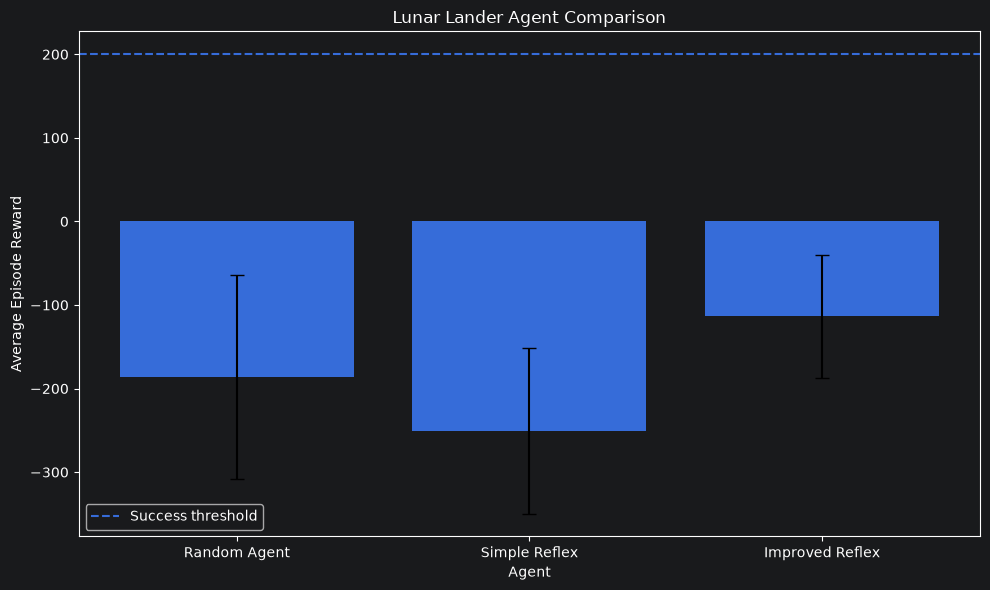


FINAL COMPARISON
Agent                    Average         Std         Min         Max     Success
----------------------------------------------------------------------
Random Agent             -186.11      122.11     -593.18       -6.16       0.00%
Simple Reflex            -250.39       99.16     -487.69      157.03       0.00%
Improved Reflex          -113.52       73.50     -200.57      267.39       2.00%


In [63]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


def random_agent(observation):
    return np.random.choice([0, 1, 2, 3])


def simple_reflex_agent(observation):
    x, y, vx, vy, angle, angular_velocity, left_leg, right_leg = observation

    if vy < -0.4:
        return 2

    return 0


def improved_reflex_agent(observation):
    x, y, vx, vy, angle, angular_velocity, left_leg, right_leg = observation

    if angle > 0.20:
        return 3

    if angle < -0.20:
        return 1

    if angular_velocity > 0.30:
        return 1

    if angular_velocity < -0.30:
        return 3

    if x > 0.15:
        if vx > 0.05:
            return 1
        return 1

    if x < -0.15:
        if vx < -0.05:
            return 3
        return 3

    if vx > 0.20:
        return 1

    if vx < -0.20:
        return 3

    if vy < -0.40:
        return 2

    if y < 0.25 and vy < -0.20:
        return 2

    return 0


def run_episode(env, agent, max_steps=1000):
    observation, info = env.reset()

    total_reward = 0.0

    for step in range(max_steps):
        action = agent(observation)

        observation, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        if terminated or truncated:
            break

    return total_reward


def evaluate_agent(env, agent, episodes=100):
    rewards = []

    for episode in range(episodes):
        reward = run_episode(env, agent)
        rewards.append(reward)

    rewards = np.array(rewards)

    average_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    min_reward = np.min(rewards)
    max_reward = np.max(rewards)
    success_rate = np.mean(rewards >= 200) * 100

    return {
        "rewards": rewards,
        "average": average_reward,
        "std": std_reward,
        "min": min_reward,
        "max": max_reward,
        "success_rate": success_rate
    }


env = gym.make("LunarLander-v3")


agents = {
    "Random Agent": random_agent,
    "Simple Reflex": simple_reflex_agent,
    "Improved Reflex": improved_reflex_agent
}


results = {}


for name, agent in agents.items():

    print("=" * 50)
    print(name)

    result = evaluate_agent(
        env,
        agent,
        episodes=100
    )

    results[name] = result

    print(f"Average reward : {result['average']:.2f}")
    print(f"Std reward     : {result['std']:.2f}")
    print(f"Minimum reward : {result['min']:.2f}")
    print(f"Maximum reward : {result['max']:.2f}")
    print(f"Success rate   : {result['success_rate']:.2f}%")


env.close()


names = list(results.keys())

average_rewards = [
    results[name]["average"]
    for name in names
]

std_rewards = [
    results[name]["std"]
    for name in names
]


plt.figure(figsize=(10, 6))

plt.bar(
    names,
    average_rewards,
    yerr=std_rewards,
    capsize=5
)

plt.axhline(
    y=200,
    linestyle="--",
    label="Success threshold"
)

plt.xlabel("Agent")
plt.ylabel("Average Episode Reward")
plt.title("Lunar Lander Agent Comparison")

plt.legend()
plt.tight_layout()
plt.show()


print()
print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)

print(
    f"{'Agent':<20}"
    f"{'Average':>12}"
    f"{'Std':>12}"
    f"{'Min':>12}"
    f"{'Max':>12}"
    f"{'Success':>12}"
)

print("-" * 70)

for name in names:

    result = results[name]

    print(
        f"{name:<20}"
        f"{result['average']:>12.2f}"
        f"{result['std']:>12.2f}"
        f"{result['min']:>12.2f}"
        f"{result['max']:>12.2f}"
        f"{result['success_rate']:>11.2f}%"
    )